In [45]:
import json
from pathlib import Path
from collections import Counter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA_DIR = Path("../data/structured/tmdb/movies")
EDA_DIR = Path("../../data/eda")

EDA_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 100)

print(f"Data directory: {DATA_DIR}")
print(f"EDA output directory: {EDA_DIR}")

Data directory: ..\data\structured\tmdb\movies
EDA output directory: ..\..\data\eda


In [46]:
movie_files = sorted(DATA_DIR.glob("*.json"))

print(f"Total JSON files found: {len(movie_files)}")
if len(movie_files) == 0:
    raise FileNotFoundError(
        f"No JSON files found in {DATA_DIR.resolve()}")

Total JSON files found: 99


In [47]:
movies = []
failed_files = []

for file_path in movie_files:
    try:
        with open(file_path, "r", encoding="utf-8") as f:
            movie = json.load(f)

        movie["_source_file"] = file_path.name
        movies.append(movie)

    except Exception as e:
        failed_files.append({
            "file": file_path.name,
            "error": str(e)
        })


print(f"Successfully loaded: {len(movies)}")
print(f"Failed to load:       {len(failed_files)}")

if failed_files:
    display(pd.DataFrame(failed_files))

Successfully loaded: 99
Failed to load:       0


In [48]:
print("First movie:")
print(json.dumps(movies[0], indent=2, ensure_ascii=False))

First movie:
{
  "movie_id": 1003596,
  "content": {
    "title": "Avengers: Doomsday",
    "original_title": "Avengers: Doomsday",
    "overview": "Beloved heroes from three distinct universes are set on a deadly collision course and face an existential threat unlike anything they've ever encountered.",
    "tagline": ""
  },
  "embedding_text": "Title: Avengers: Doomsday\n\nOverview: Beloved heroes from three distinct universes are set on a deadly collision course and face an existential threat unlike anything they've ever encountered.\n\nGenres: Science Fiction, Action, Adventure\n\nCollection: The Avengers Collection\n\nProduction Companies: Marvel Studios, Kevin Feige Productions, AGBO\n\nProduction Countries: United States of America\n\nSpoken Languages: English",
  "metadata": {
    "imdb_id": "tt21357150",
    "release_date": "2026-12-16",
    "release_year": 2026,
    "original_language": "en",
    "origin_country": [
      "US"
    ],
    "runtime_minutes": 165,
    "status":

In [49]:
EXPECTED_TOP_LEVEL = {
    "movie_id",
    "content",
    "embedding_text",
    "metadata",
    "relationships",
    "assets"
}

schema_issues = []

for movie in movies:
    movie_id = movie.get("movie_id")

    actual_keys = set(movie.keys())

    missing_keys = EXPECTED_TOP_LEVEL - actual_keys
    extra_keys = actual_keys - EXPECTED_TOP_LEVEL - {"_source_file"}

    if missing_keys or extra_keys:
        schema_issues.append({
            "movie_id": movie_id,
            "file": movie.get("_source_file"),
            "missing_keys": list(missing_keys),
            "extra_keys": list(extra_keys)
        })


schema_issues_df = pd.DataFrame(schema_issues)

print(f"Movies with top-level schema issues: {len(schema_issues_df)}")

if not schema_issues_df.empty:
    display(schema_issues_df)

Movies with top-level schema issues: 0


In [50]:
EXPECTED_CONTENT = {
    "title",
    "original_title",
    "overview",
    "tagline"
}

EXPECTED_METADATA = {
    "imdb_id",
    "release_date",
    "release_year",
    "original_language",
    "origin_country",
    "runtime_minutes",
    "status",
    "genres",
    "spoken_languages",
    "production_countries",
    "budget",
    "revenue",
    "popularity",
    "vote_average",
    "vote_count"
}

EXPECTED_RELATIONSHIPS = {
    "collection",
    "production_companies"
}

EXPECTED_ASSETS = {
    "homepage",
    "poster_path",
    "backdrop_path"
}


nested_schema_issues = []

for movie in movies:
    movie_id = movie.get("movie_id")

    for section_name, expected_keys in [
        ("content", EXPECTED_CONTENT),
        ("metadata", EXPECTED_METADATA),
        ("relationships", EXPECTED_RELATIONSHIPS),
        ("assets", EXPECTED_ASSETS),
    ]:
        section = movie.get(section_name)

        if not isinstance(section, dict):
            nested_schema_issues.append({
                "movie_id": movie_id,
                "section": section_name,
                "issue": "Section is not a dictionary"
            })
            continue

        missing = expected_keys - set(section.keys())

        if missing:
            nested_schema_issues.append({
                "movie_id": movie_id,
                "section": section_name,
                "issue": f"Missing keys: {list(missing)}"
            })


nested_schema_df = pd.DataFrame(nested_schema_issues)

print(f"Nested schema issues: {len(nested_schema_df)}")

if not nested_schema_df.empty:
    display(nested_schema_df)

Nested schema issues: 0


In [51]:
rows = []

for movie in movies:

    content = movie.get("content", {})
    metadata = movie.get("metadata", {})
    relationships = movie.get("relationships", {})
    assets = movie.get("assets", {})

    collection = relationships.get("collection")

    rows.append({
        "movie_id": movie.get("movie_id"),

        "title": content.get("title"),
        "original_title": content.get("original_title"),
        "overview": content.get("overview"),
        "tagline": content.get("tagline"),

        "embedding_text": movie.get("embedding_text"),

        "imdb_id": metadata.get("imdb_id"),
        "release_date": metadata.get("release_date"),
        "release_year": metadata.get("release_year"),
        "original_language": metadata.get("original_language"),
        "origin_country": metadata.get("origin_country"),
        "runtime_minutes": metadata.get("runtime_minutes"),
        "status": metadata.get("status"),

        "genres": metadata.get("genres"),
        "spoken_languages": metadata.get("spoken_languages"),
        "production_countries": metadata.get("production_countries"),

        "budget": metadata.get("budget"),
        "revenue": metadata.get("revenue"),
        "popularity": metadata.get("popularity"),
        "vote_average": metadata.get("vote_average"),
        "vote_count": metadata.get("vote_count"),

        "collection_id": (
            collection.get("id")
            if collection else None
        ),

        "collection_name": (
            collection.get("name")
            if collection else None
        ),

        "production_companies": relationships.get(
            "production_companies", []
        ),

        "homepage": assets.get("homepage"),
        "poster_path": assets.get("poster_path"),
        "backdrop_path": assets.get("backdrop_path"),

        "_source_file": movie.get("_source_file")
    })


df = pd.DataFrame(rows)

print(f"DataFrame shape: {df.shape}")

display(df.head())

DataFrame shape: (99, 28)


,movie_id,title,original_title,overview,tagline,embedding_text,imdb_id,release_date,release_year,original_language,origin_country,runtime_minutes,status,genres,spoken_languages,production_countries,budget,revenue,popularity,vote_average,vote_count,collection_id,collection_name,production_companies,homepage,poster_path,backdrop_path,_source_file
0,1003596,Avengers: Doomsday,Avengers: Doomsday,Beloved heroes from three distinct universes are set on a deadly collision course and face an ex...,,Title: Avengers: Doomsday\n\nOverview: Beloved heroes from three distinct universes are set on a...,tt21357150,2026-12-16,2026,en,[US],165,Post Production,"[Science Fiction, Action, Adventure]",[English],[United States of America],0,0,59.8434,0.000,0,86311.0,The Avengers Collection,"[{'id': 420, 'name': 'Marvel Studios', 'origin_country': 'US'}, {'id': 176762, 'name': 'Kevin Fe...",https://www.marvel.com/movies/avengers-doomsday,/jzPwsojjFStf5lR5Nm07w2hH56G.jpg,/s4v0UX1anfXm0UvloLsTTJ4v222.jpg,1003596.json
1,10138,Iron Man 2,Iron Man 2,"With the world now aware of his dual life as the armored superhero Iron Man, billionaire invento...","It's not the armor that makes the hero, but the man inside.","Title: Iron Man 2\n\nTagline: It's not the armor that makes the hero, but the man inside.\n\nOve...",tt1228705,2010-04-28,2010,en,[US],124,Released,"[Adventure, Action, Science Fiction]","[English, Russian, French]",[United States of America],200000000,623933331,44.8532,6.855,22948,131292.0,Iron Man Collection,"[{'id': 420, 'name': 'Marvel Studios', 'origin_country': 'US'}, {'id': 7297, 'name': 'Fairview E...",https://www.marvel.com/movies/iron-man-2,/6WBeq4fCfn7AN0o21W9qNcRF2l9.jpg,/7lmBufEG7P7Y1HClYK3gCxYrkgS.jpg,10138.json
2,1032863,The Love Hypothesis,The Love Hypothesis,"Olive Smith, a biology PhD candidate, and Dr. Adam Carlsen, a hotshot professor and well-known t...",Fake dating. Real chemistry.,"Title: The Love Hypothesis\n\nTagline: Fake dating. Real chemistry.\n\nOverview: Olive Smith, a ...",tt22526100,2026-09-23,2026,en,[US],112,Released,"[Romance, Comedy]",[English],[United States of America],0,0,273.1621,8.336,137,NaN,NaN,"[{'id': 2531, 'name': 'MRC', 'origin_country': 'US'}, {'id': 210099, 'name': 'Amazon MGM Studios...",https://www.amazon.com/dp/B0H4WZS7VX,/vfZxVHextAGC70zrNhS8lsROqP1.jpg,/o7Oy9Gbx1CCyaweL8xUhtMW4Puq.jpg,1032863.json
3,1058424,Hope,호프,"In the remote South Korean village of Hope Harbor, police chief Bum-seok and officer Sung-ae are...",Is this how it ends?,Title: Hope\n\nOriginal Title: 호프\n\nTagline: Is this how it ends?\n\nOverview: In the remote So...,tt27369017,2026-07-15,2026,ko,[KR],157,Released,"[Science Fiction, Mystery, Action]",[Korean],[South Korea],46000000,41212538,55.1846,7.400,88,NaN,NaN,"[{'id': 196800, 'name': 'Forged Films', 'origin_country': 'KR'}, {'id': 91505, 'name': 'Plus M E...",https://www.neonrated.com/film/hope,/1n37BJchWHLiSYQkuFxe5KjB951.jpg,/hrCTKrc3Tz2wbPOt5rcrlAhqF11.jpg,1058424.json
4,1081003,Supergirl,Supergirl,"When an unexpected and ruthless adversary strikes too close to home, Kara Zor-El, aka Supergirl,...",Truth. Justice. Whatever.,Title: Supergirl\n\nTagline: Truth. Justice. Whatever.\n\nOverview: When an unexpected and ruthl...,tt8814476,2026-06-24,2026,en,[US],108,Released,"[Action, Adventure, Science Fiction]",[English],[United States of America],175000000,126366532,63.9932,6.678,2399,NaN,NaN,"[{'id': 184898, 'name': 'DC Studios', 'origin_country': 'US'}, {'id': 94218, 'name': 'Troll Cour...",https://www.supergirlmovie.com,/uhzRnTW4DM13UQBvZP3eVNzQTuz.jpg,/heZQmyNvkH236ha2M3JckdUQQqb.jpg,1081003.json


In [52]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 99 entries, 0 to 98
Data columns (total 28 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   movie_id              99 non-null     int64  
 1   title                 99 non-null     str    
 2   original_title        99 non-null     str    
 3   overview              99 non-null     str    
 4   tagline               99 non-null     str    
 5   embedding_text        99 non-null     str    
 6   imdb_id               97 non-null     str    
 7   release_date          99 non-null     str    
 8   release_year          99 non-null     int64  
 9   original_language     99 non-null     str    
 10  origin_country        99 non-null     object 
 11  runtime_minutes       99 non-null     int64  
 12  status                99 non-null     str    
 13  genres                99 non-null     object 
 14  spoken_languages      99 non-null     object 
 15  production_countries  99 non-null   

In [53]:
numeric_columns = [
    "release_year",
    "runtime_minutes",
    "budget",
    "revenue",
    "popularity",
    "vote_average",
    "vote_count"
]

display(df[numeric_columns].describe().T)

,count,mean,std,min,25%,50%,75%,max
release_year,99.0,2.020455e+03,1.177014e+01,1970.0000,2022.0000,2.026000e+03,2.026000e+03,2.026000e+03
runtime_minutes,99.0,1.154747e+02,3.296515e+01,0.0000,95.0000,1.080000e+02,1.410000e+02,2.010000e+02
budget,99.0,7.198333e+07,9.166131e+07,0.0000,0.0000,2.500000e+07,1.375000e+08,3.560000e+08
revenue,99.0,3.710161e+08,5.986157e+08,0.0000,0.0000,4.121254e+07,5.314005e+08,2.799439e+09
popularity,99.0,1.025664e+02,9.496805e+01,33.0166,55.3363,7.099350e+01,9.927520e+01,6.335085e+02
vote_average,99.0,6.960030e+00,1.744195e+00,0.0000,6.3340,7.472000e+00,8.064000e+00,9.200000e+00
vote_count,99.0,6.161788e+03,1.085002e+04,0.0000,52.5000,7.870000e+02,4.387000e+03,4.124700e+04


In [54]:
ZERO_MEANS_MISSING = {
    "runtime_minutes",
    "budget",
    "revenue"
}

def zero_to_none(value):
    """
    TMDB uses 0 for some unavailable numeric fields.
    Treat 0 as missing.
    """
    if value == 0:
        return None

    return value

for col in ZERO_MEANS_MISSING:
    df[col] = df[col].apply(zero_to_none)

In [90]:
# verify that the NaN values have come in place

for col in ZERO_MEANS_MISSING:
    num_missing = df[col].isna().sum()
    print(f"{col}: {num_missing} missing values")

revenue: 33 missing values
budget: 33 missing values
runtime_minutes: 2 missing values


In [56]:
missing = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percentage": (
        df.isna().mean() * 100
    ).round(2)
})

missing = missing.sort_values(
    "missing_percentage",
    ascending=False
)

display(missing)

,missing_count,missing_percentage
collection_id,60,60.61
collection_name,60,60.61
budget,33,33.33
revenue,33,33.33
runtime_minutes,2,2.02
imdb_id,2,2.02
backdrop_path,2,2.02
embedding_text,0,0.00
overview,0,0.00
original_title,0,0.00


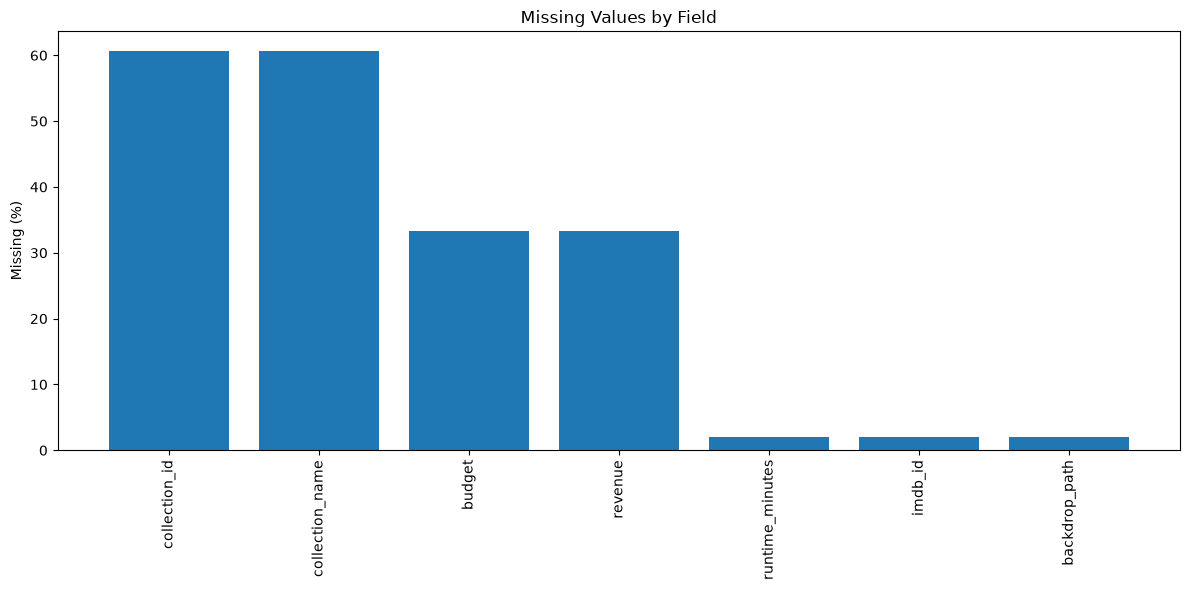

In [57]:
missing_nonzero = missing[
    missing["missing_count"] > 0
].copy()

if not missing_nonzero.empty:

    plt.figure(figsize=(12, 6))

    plt.bar(
        missing_nonzero.index,
        missing_nonzero["missing_percentage"]
    )

    plt.xticks(
        rotation=90
    )

    plt.ylabel("Missing (%)")
    plt.title("Missing Values by Field")
    plt.tight_layout()

    plt.show()

In [58]:
duplicate_ids = df[
    df["movie_id"].duplicated(keep=False)
].sort_values("movie_id")

print(f"Duplicate movie IDs: {len(duplicate_ids)}")

if not duplicate_ids.empty:
    display(duplicate_ids[
        ["movie_id", "title", "_source_file"]
    ])

Duplicate movie IDs: 0


In [59]:
duplicate_titles = df[
    df["title"].duplicated(keep=False)
].sort_values("title")

print(f"Rows with duplicate titles: {len(duplicate_titles)}")

if not duplicate_titles.empty:
    display(
        duplicate_titles[
            ["movie_id", "title", "release_year"]
        ]
    )

Rows with duplicate titles: 0


In [60]:
critical_fields = [
    "movie_id",
    "title",
    "overview",
    "embedding_text"
]

critical_issues = []

for field in critical_fields:

    missing_count = df[field].isna().sum()

    empty_count = (
        df[field]
        .fillna("")
        .astype(str)
        .str.strip()
        .eq("")
        .sum()
    )

    critical_issues.append({
        "field": field,
        "missing": missing_count,
        "empty": empty_count
    })


critical_issues_df = pd.DataFrame(critical_issues)

display(critical_issues_df)

,field,missing,empty
0,movie_id,0,0
1,title,0,0
2,overview,0,0
3,embedding_text,0,0


In [61]:
df["embedding_text_chars"] = (
    df["embedding_text"]
    .fillna("")
    .astype(str)
    .str.len()
)

df["embedding_text_words"] = (
    df["embedding_text"]
    .fillna("")
    .astype(str)
    .str.split()
    .str.len()
)

display(
    df[
        [
            "embedding_text_chars",
            "embedding_text_words"
        ]
    ].describe()
)

,embedding_text_chars,embedding_text_words
count,99.000000,99.000000
mean,558.808081,81.151515
std,141.027547,22.343955
min,68.000000,11.000000
25%,462.500000,64.500000
50%,554.000000,80.000000
75%,651.500000,97.500000
max,944.000000,155.000000


In [62]:
short_embeddings = df[
    df["embedding_text_words"] < 10
].sort_values("embedding_text_words")

print(
    f"Movies with fewer than 10 words in embedding text: "
    f"{len(short_embeddings)}"
)

display(
    short_embeddings[
        [
            "movie_id",
            "title",
            "embedding_text"
        ]
    ].head(30)
)

Movies with fewer than 10 words in embedding text: 0


,movie_id,title,embedding_text


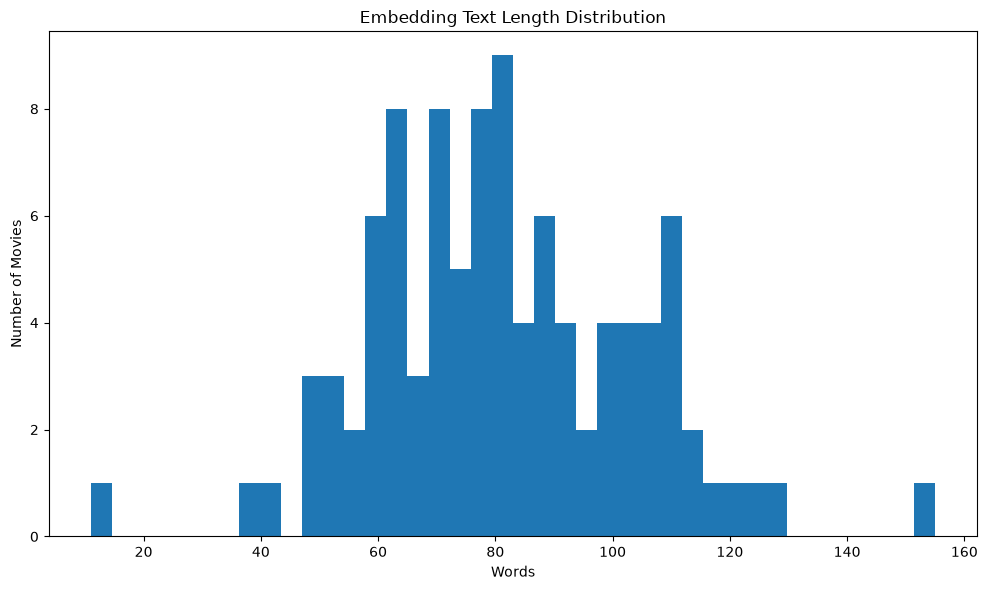

In [63]:
plt.figure(figsize=(10, 6))

plt.hist(
    df["embedding_text_words"].dropna(),
    bins=40
)

plt.xlabel("Words")
plt.ylabel("Number of Movies")
plt.title("Embedding Text Length Distribution")

plt.tight_layout()
plt.show()

In [64]:
current_year = pd.Timestamp.now().year

invalid_years = df[
    (df["release_year"].notna()) &
    (
        (df["release_year"] < 1800) |
        (df["release_year"] > current_year)
    )
]

print(f"Invalid release years: {len(invalid_years)}")

if not invalid_years.empty:
    display(
        invalid_years[
            ["movie_id", "title", "release_year"]
        ]
    )

Invalid release years: 0


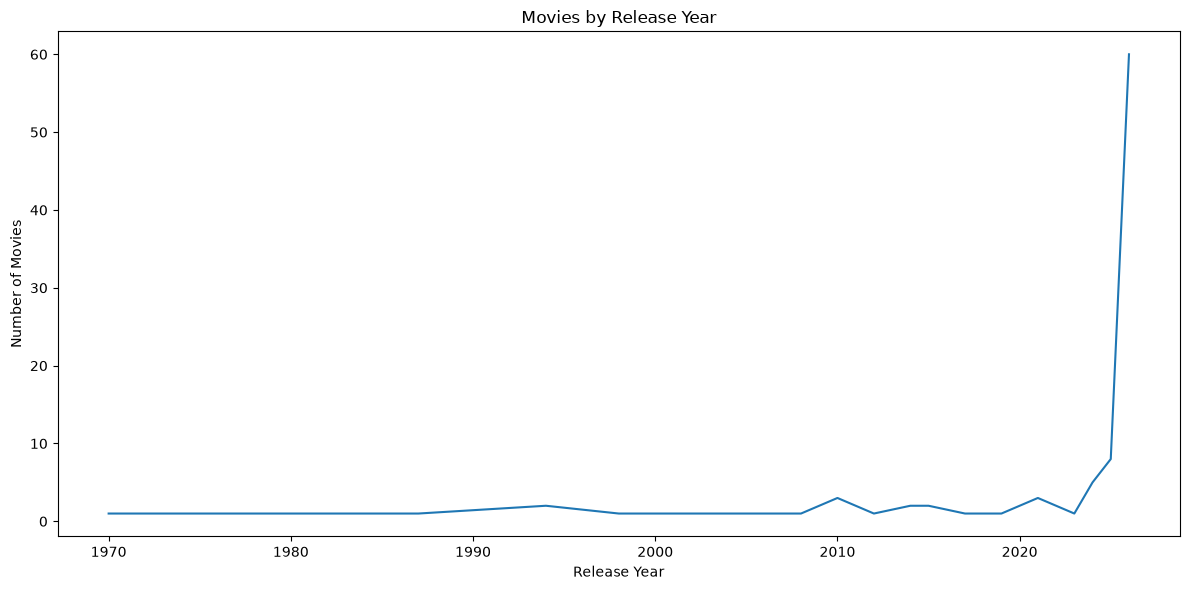

In [65]:
year_counts = (
    df["release_year"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(12, 6))

plt.plot(
    year_counts.index,
    year_counts.values
)

plt.xlabel("Release Year")
plt.ylabel("Number of Movies")
plt.title("Movies by Release Year")

plt.tight_layout()
plt.show()

In [66]:
invalid_runtime = df[
    (df["runtime_minutes"].notna()) &
    (
        (df["runtime_minutes"] <= 0) |
        (df["runtime_minutes"] > 500)
    )
]

print(f"Suspicious runtimes: {len(invalid_runtime)}")

if not invalid_runtime.empty:
    display(
        invalid_runtime[
            [
                "movie_id",
                "title",
                "runtime_minutes"
            ]
        ]
    )

Suspicious runtimes: 0


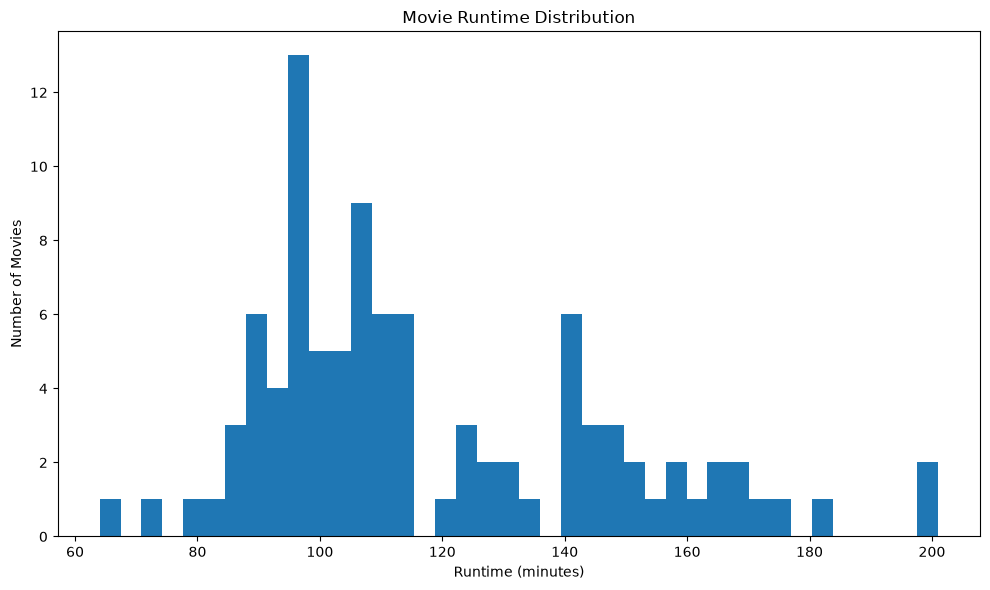

In [67]:
plt.figure(figsize=(10, 6))

plt.hist(
    df["runtime_minutes"].dropna(),
    bins=40
)

plt.xlabel("Runtime (minutes)")
plt.ylabel("Number of Movies")
plt.title("Movie Runtime Distribution")

plt.tight_layout()
plt.show()

In [68]:
genre_series = (
    df["genres"]
    .dropna()
    .explode()
)

genre_counts = (
    genre_series
    .value_counts()
)

display(genre_counts)

genres
Action             40
Adventure          36
Science Fiction    33
Thriller           30
Comedy             29
Drama              18
Horror             16
Fantasy            16
Animation          14
Family             13
Romance            11
Crime              10
Mystery             6
War                 2
TV Movie            1
History             1
Music               1
Name: count, dtype: int64

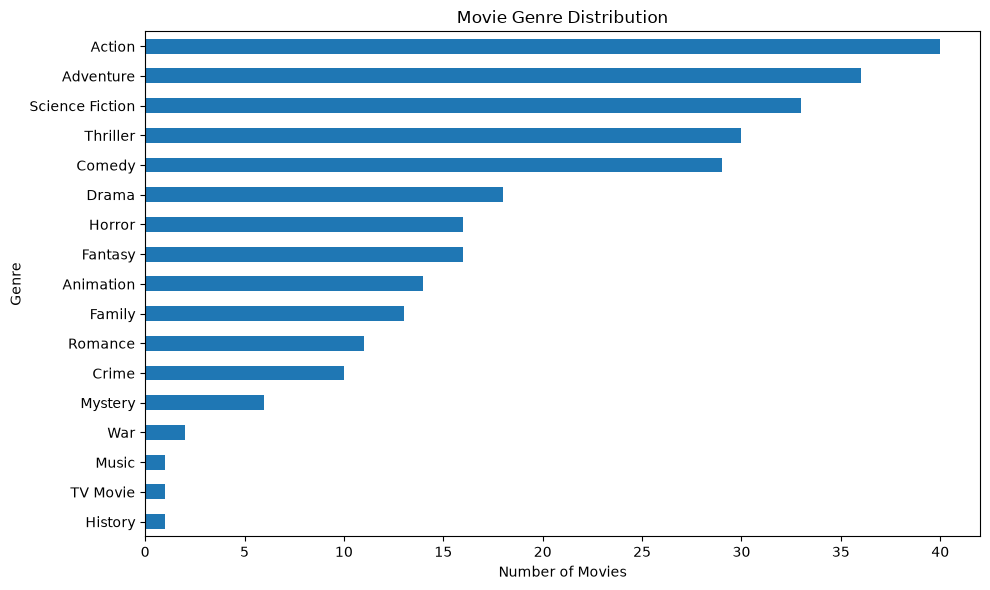

In [69]:
plt.figure(figsize=(10, 6))

genre_counts.sort_values().plot(
    kind="barh"
)

plt.xlabel("Number of Movies")
plt.ylabel("Genre")
plt.title("Movie Genre Distribution")

plt.tight_layout()
plt.show()

In [70]:
language_counts = (
    df["original_language"]
    .value_counts()
)

display(language_counts.head(30))

original_language
en    81
ko     4
es     3
zh     2
ja     2
id     2
ta     2
fr     2
it     1
Name: count, dtype: int64

In [71]:
spoken_language_counts = (
    df["spoken_languages"]
    .dropna()
    .explode()
    .value_counts()
)

display(
    spoken_language_counts.head(30)
)

spoken_languages
English       79
Spanish       10
French         7
Russian        6
Korean         6
Japanese       6
Mandarin       5
Italian        4
Portuguese     3
Indonesian     3
Tagalog        3
Latin          2
Tamil          2
Hindi          2
Xhosa          2
Aymara         1
Arabic         1
Thai           1
Telugu         1
Swahili        1
Finnish        1
Hungarian      1
Somali         1
Polish         1
Name: count, dtype: int64

In [72]:
country_counts = (
    df["production_countries"]
    .dropna()
    .explode()
    .value_counts()
)

display(
    country_counts.head(30)
)

production_countries
United States of America    76
United Kingdom              18
Canada                       7
South Korea                  5
France                       5
Spain                        4
Australia                    4
Japan                        4
China                        3
Germany                      3
Italy                        3
New Zealand                  2
Hong Kong                    2
Poland                       2
Indonesia                    2
India                        2
Ukraine                      1
Brazil                       1
Argentina                    1
Denmark                      1
Dominican Republic           1
Mexico                       1
Greece                       1
Sweden                       1
Name: count, dtype: int64

In [73]:
origin_country_counts = (
    df["origin_country"]
    .dropna()
    .explode()
    .value_counts()
)

display(
    origin_country_counts.head(30)
)

origin_country
US    74
GB     8
KR     4
HK     3
AU     2
CA     2
CN     2
JP     2
PL     2
ID     2
IN     2
FR     2
AR     1
DK     1
ES     1
DO     1
MX     1
IT     1
Name: count, dtype: int64

In [74]:
invalid_ratings = df[
    (df["vote_average"].notna()) &
    (
        (df["vote_average"] < 0) |
        (df["vote_average"] > 10)
    )
]

print(f"Invalid ratings: {len(invalid_ratings)}")

if not invalid_ratings.empty:
    display(
        invalid_ratings[
            [
                "movie_id",
                "title",
                "vote_average"
            ]
        ]
    )

Invalid ratings: 0


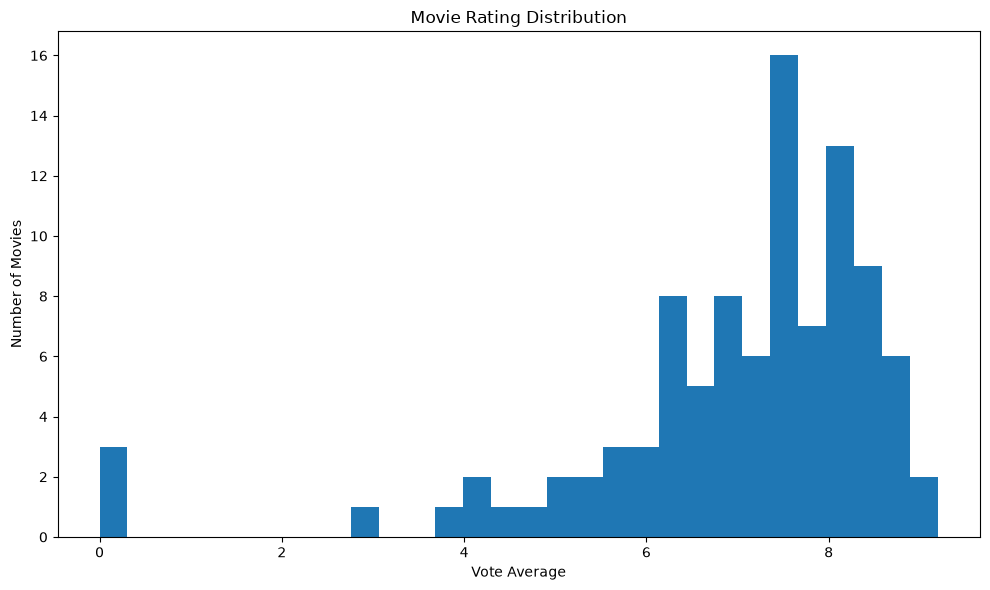

In [75]:
plt.figure(figsize=(10, 6))

plt.hist(
    df["vote_average"].dropna(),
    bins=30
)

plt.xlabel("Vote Average")
plt.ylabel("Number of Movies")
plt.title("Movie Rating Distribution")

plt.tight_layout()
plt.show()

In [76]:
display(
    df["popularity"].describe()
)

count     99.000000
mean     102.566423
std       94.968048
min       33.016600
25%       55.336300
50%       70.993500
75%       99.275200
max      633.508500
Name: popularity, dtype: float64

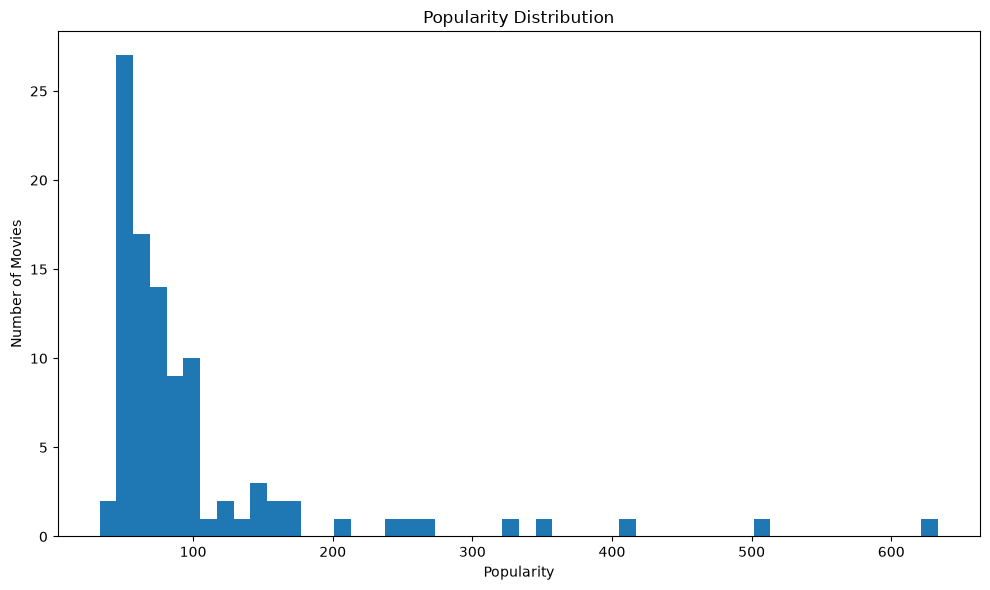

In [77]:
plt.figure(figsize=(10, 6))

plt.hist(
    df["popularity"].dropna(),
    bins=50
)

plt.xlabel("Popularity")
plt.ylabel("Number of Movies")
plt.title("Popularity Distribution")

plt.tight_layout()
plt.show()

In [78]:
financial_columns = [
    "budget",
    "revenue"
]

display(
    df[financial_columns].describe().T
)

,count,mean,std,min,25%,50%,75%,max
budget,66.0,1.079750e+08,9.338808e+07,100000.0,25000000.00,81000000.0,178750000.0,3.560000e+08
revenue,66.0,5.565241e+08,6.598785e+08,85294.0,41388132.25,283699626.5,852966038.0,2.799439e+09


In [79]:
for column in ["budget", "revenue"]:

    zero_count = (df[column] == 0).sum()

    print(
        f"{column}: {zero_count} movies with value 0"
    )

budget: 0 movies with value 0
revenue: 0 movies with value 0


In [80]:
status_counts = (
    df["status"]
    .value_counts(dropna=False)
)

display(status_counts)

status
Released           97
Post Production     2
Name: count, dtype: int64

In [81]:
collection_count = (
    df["collection_name"]
    .notna()
    .sum()
)

total_movies = len(df)

print(
    f"Movies belonging to a collection: "
    f"{collection_count}/{total_movies}"
)

print(
    f"Percentage: "
    f"{collection_count / total_movies * 100:.2f}%"
)

Movies belonging to a collection: 39/99
Percentage: 39.39%


In [82]:
collection_counts = (
    df["collection_name"]
    .dropna()
    .value_counts()
)

display(
    collection_counts.head(30)
)

collection_name
The Avengers Collection                      4
Toy Story Collection                         2
Practical Magic Collection                   2
Spider-Man (MCU) Collection                  2
Iron Man Collection                          1
Zootopia Collection                          1
Fall Collection                              1
The Wild Robot Collection                    1
PAW Patrol (Theatrical) Collection           1
The Lord of the Rings Collection             1
The Priests Collection                       1
The Super Mario Collection                   1
Jurassic Park Collection                     1
Scary Movie Collection                       1
Demon Slayer: Kimetsu no Yaiba Collection    1
Minions Collection                           1
Ghost in the Cell Collection                 1
Inside Out Collection                        1
The Thundermans Collection                   1
The Dark Knight Collection                   1
Batman: Knightfall Collection               

In [83]:
def contains_non_ascii(value):
    if pd.isna(value):
        return False

    return any(ord(char) > 127 for char in str(value))


df["title_has_unicode"] = df["title"].apply(
    contains_non_ascii
)

df["overview_has_unicode"] = df["overview"].apply(
    contains_non_ascii
)

print(
    "Titles containing non-ASCII characters:",
    df["title_has_unicode"].sum()
)

print(
    "Overviews containing non-ASCII characters:",
    df["overview_has_unicode"].sum()
)

Titles containing non-ASCII characters: 1
Overviews containing non-ASCII characters: 19


In [84]:
unicode_movies = df[
    df["title_has_unicode"]
]

display(
    unicode_movies[
        [
            "movie_id",
            "title",
            "original_title",
            "original_language"
        ]
    ].head(50)
)

,movie_id,title,original_title,original_language
95,895954,母女汽车中心,莫尼卡中心,ko


In [85]:
asset_columns = [
    "homepage",
    "poster_path",
    "backdrop_path"
]

asset_summary = pd.DataFrame({
    "available": df[asset_columns].notna().sum(),
    "missing": df[asset_columns].isna().sum(),
})

asset_summary["available_percentage"] = (
    asset_summary["available"]
    / len(df)
    * 100
).round(2)

display(asset_summary)

,available,missing,available_percentage
homepage,99,0,100.00
poster_path,99,0,100.00
backdrop_path,97,2,97.98


In [86]:
company_names = []

for companies in df["production_companies"].dropna():

    if isinstance(companies, list):

        for company in companies:

            if isinstance(company, dict):
                name = company.get("name")

                if name:
                    company_names.append(name)


company_counts = (
    pd.Series(company_names)
    .value_counts()
)

display(
    company_counts.head(30)
)

Warner Bros. Pictures            9
Marvel Studios                   8
Universal Pictures               7
Amazon MGM Studios               6
Columbia Pictures                5
Domain Entertainment             4
Pascal Pictures                  4
Pixar                            3
Capstone Pictures                3
Illumination                     3
Paramount Pictures               3
Syncopy                          3
Legendary Pictures               3
TSG Entertainment                3
Kevin Feige Productions          2
AGBO                             2
Fairview Entertainment           2
Marvel Entertainment             2
Troll Court Entertainment        2
21 Laps Entertainment            2
Walt Disney Animation Studios    2
Tea Shop Productions             2
Rabbits Black                    2
Blue Rider Pictures              2
MUBI                             2
Maximum Effort                   2
DreamWorks Animation             2
Nickelodeon Movies               2
New Line Cinema     

In [87]:
health_report = {
    "total_movies": len(df),

    "duplicate_movie_ids": int(
        df["movie_id"].duplicated().sum()
    ),

    "missing_titles": int(
        df["title"].isna().sum()
    ),

    "missing_overviews": int(
        df["overview"].isna().sum()
    ),

    "empty_embedding_text": int(
        df["embedding_text"]
        .fillna("")
        .str.strip()
        .eq("")
        .sum()
    ),

    "missing_release_dates": int(
        df["release_date"].isna().sum()
    ),

    "missing_runtime": int(
        df["runtime_minutes"].isna().sum()
    ),

    "missing_genres": int(
        df["genres"].apply(
            lambda x: not x if isinstance(x, list) else True
        ).sum()
    ),

    "missing_ratings": int(
        df["vote_average"].isna().sum()
    ),

    "unicode_titles": int(
        df["title_has_unicode"].sum()
    ),

    "movies_with_posters": int(
        df["poster_path"].notna().sum()
    ),

    "movies_with_backdrops": int(
        df["backdrop_path"].notna().sum()
    ),

    "movies_with_homepage": int(
        df["homepage"].notna().sum()
    )
}

health_report_df = pd.DataFrame(
    health_report.items(),
    columns=["metric", "value"]
)

display(health_report_df)

,metric,value
0,total_movies,99
1,duplicate_movie_ids,0
2,missing_titles,0
3,missing_overviews,0
4,empty_embedding_text,0
5,missing_release_dates,0
6,missing_runtime,2
7,missing_genres,1
8,missing_ratings,0
9,unicode_titles,1


In [88]:
health_report_df.to_csv(
    EDA_DIR / "dataset_health.csv",
    index=False
)

missing.to_csv(
    EDA_DIR / "missing_values.csv"
)

genre_counts.to_csv(
    EDA_DIR / "genre_distribution.csv"
)

language_counts.to_csv(
    EDA_DIR / "language_distribution.csv"
)

collection_counts.to_csv(
    EDA_DIR / "collection_distribution.csv"
)

print(f"EDA results saved to: {EDA_DIR}")

EDA results saved to: ..\..\data\eda


In [89]:
eda_csv = EDA_DIR / "movies_eda.csv"

df.to_csv(
    eda_csv,
    index=False,
    encoding="utf-8"
)

print(f"Saved: {eda_csv}")

Saved: ..\..\data\eda\movies_eda.csv
